## Betatron Oscillations Stability Study

Notebook to investigate the stability of the betatron oscillations as the module of K is increased, for a FODO arrangement with a fixed distance $d$ between the quadrupoles

### Core idea:

Given that $\beta(s)$ = $\zeta²(s)$, we know that $\zeta(s)$ is the single-valued continuous function which satisfies

\begin{equation}
    \zeta'' + K(s)\zeta - \frac{1}{\zeta³} = 0
\end{equation}

In regions where $K(s)$ is a constant, the equation above is equivalent to the motion of a particle (of coordinate $\zeta$) whose potential energy is

\begin{equation}
    V(\zeta) = K\zeta^2 + \frac{1}{\zeta^2}
\end{equation}

This, together with 

\begin{equation}
    \zeta'' = -\frac{d}{d \zeta}(V)
\end{equation}
gives an intuitive way of understanding the behavior of $\zeta$, being specified the values of $K$.

#### Potential Energy Shape

Since $K$ can be negative (defocusing), zero (drift) or positive (focusing), there are 3 main possibilities for the potential:

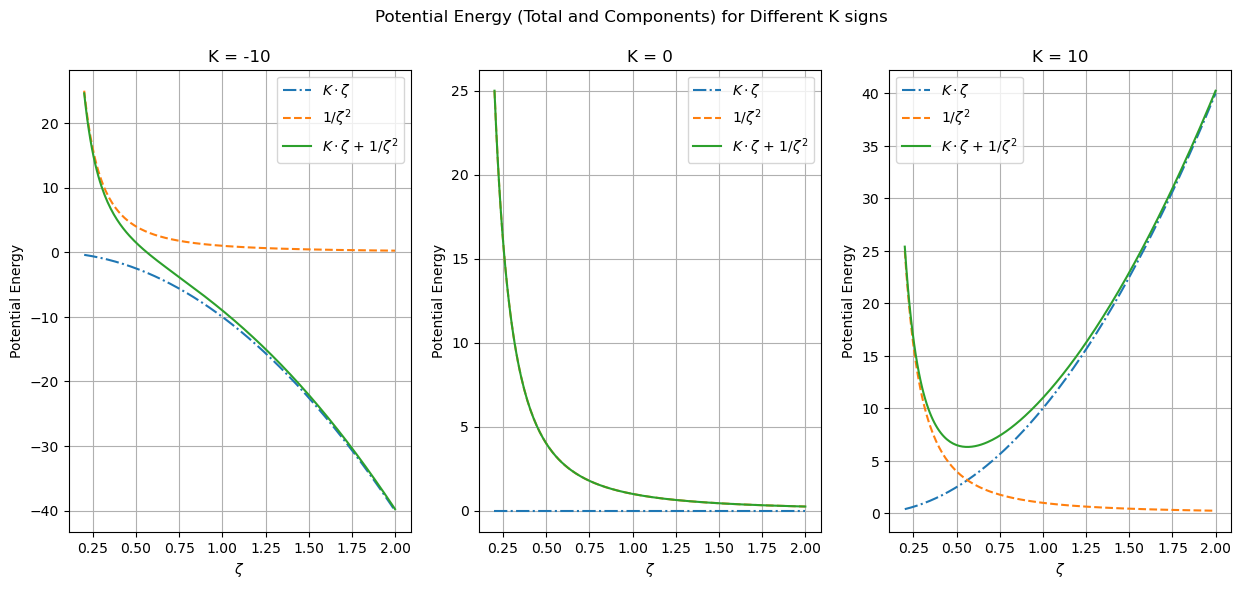

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pymodels
import pyaccel

K = 10 # Module of quadrupoles' strength

Kd = -K # Defocusing quadrupole strength
Ko = 0 # Drift space (zero strength)
Kf = K # Focusing quadrupole strength

K_values = [Kd, Ko, Kf]

zeta = np.linspace(0.2, 2, 200)

def V(K, zeta):
    """Returns the potential energy components
    (1) Quadrupole potential, (2) "Centrifugal barrier", (3) Total potential."""
    return K*zeta**2, 1/zeta**2, K*zeta**2 + 1/zeta**2 

plt.figure(figsize=(15, 6))
for K in K_values:
    V_quad, V_cent, V_total = V(K, zeta)
    plt.subplot(1, 3, K_values.index(K) + 1)
    plt.plot(zeta, V_quad, label=r'$K\cdot \zeta$', linestyle='-.')
    plt.plot(zeta, V_cent, label=r'$1/\zeta^2$', linestyle='--')
    plt.plot(zeta, V_total, label=r'$K\cdot \zeta$ + $1/\zeta^2$')
    plt.title(f'K = {K}')
    plt.xlabel(r'$\zeta$')
    plt.ylabel('Potential Energy')
    plt.grid(True)
    plt.legend()

plt.suptitle('Potential Energy (Total and Components) for Different K signs')
plt.show()


### Building the FODO line

The FODO line will consist of a half focusing quadrupole (QF), followed by a defocusing quadrupole (QD), followed by another half focusing quadrupole (QF), with drift spaces in between.

The quadrupoles have lenght $l$ and strength $K$ (focal length $f = 1/kl$), and the distance between quadrupoles' centers is $L$.

Entering more into the theory, the important quantity characterizing a quadrupole is its "*integrated force*", or *focal strength*:

\begin{equation}
    Kl \triangleq f^{-1} = -\frac{\Delta x'}{x}
\end{equation}

*Derivation:*

\begin{equation}
    \frac{d x'}{d s} = -K(s)x  \implies  \Delta x' = -K(s) x\cdot \Delta s = -K(s) x\cdot l
\end{equation}

\begin{equation}
    \implies  Kl = -\frac{\Delta x'}{x}
\end{equation}


Considering the thin lens approximation ($l << f$), one important constraint for stability will be:

\begin{equation}
    f \ge \frac{L}{2} \implies \frac{1}{Kl} \ge \frac{L}{2} \implies K \le \frac{2}{lL}
\end{equation}

#### Quickly checking Sirius Quadrupoles' Strength through Pyaccel

In [3]:
model_sirius = pymodels.si.create_accelerator()

pymodels.si.families.families_quadrupoles()

['QFA',
 'QDA',
 'QFB',
 'QDB1',
 'QDB2',
 'QFP',
 'QDP1',
 'QDP2',
 'Q1',
 'Q2',
 'Q3',
 'Q4']

In [4]:
fam_data = pymodels.si.get_family_data(model_sirius)
print('QFA indices:', fam_data['QFA']['index'],'\n')
print(model_sirius[18], '\n')

print('Kl =', f'{model_sirius[18].KL:.4f}', 'm⁻¹  => ', 'f =', f'{1/model_sirius[18].KL:.4f}', 'm')

QFA indices: [[18], [1334], [1358], [2680], [2702], [4028], [4052], [5380], [5404], [6729]] 

fam_name   : QFA 
pass_method: str_mpole_symplectic4_pass 
length     : 0.2 m
nr_steps   : 14 
polynom_b  : [ 0.00000000e+00  3.57317772e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00 -6.33975204e+04  0.00000000e+00  0.00000000e+00
  0.00000000e+00  1.37951798e+13  0.00000000e+00  0.00000000e+00
  0.00000000e+00 -2.61580732e+20] 1/m¹, 1/m², 1/m³, ...
vchamber   : 2 
hmin       : -0.012 m
hmax       : 0.012 m
vmin       : -0.012 m
vmax       : 0.012 m 

Kl = 0.7146 m⁻¹  =>  f = 1.3993 m


#### Building $K(s)$

First of all, let's build and plot the corresponding $K(s)$ profile

l =  0.1 m 
L =  1.0 m 
K_max = 20.0 m⁻²


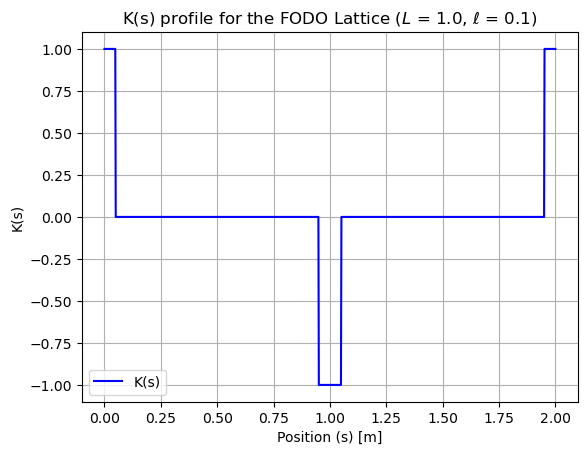

In [5]:
l = 0.1 # [m]
L = 1 # [m]

K_max = 2 / (l * L)
print('l = ', f'{l:.1f}', 'm', '\nL = ', f'{L:.1f}', 'm', '\nK_max =', K_max, 'm⁻²')

K = 1

s = np.linspace(0, 2*L, 1000)

# Define the conditions for the piecewise function
conditions = [
    s < l/2,                            # Condition for the first 1/2 QF
    (s >= l/2) & (s < L - l/2),         # Condition for the first drift
    (s >= L - l/2) & (s < L + l/2),     # Condition for the QD
    (s >= L + l/2) & (s < 2*L - l/2),   # Condition for the second drift
    (s >= 2*L - l/2) & (s < 2*L + l/2)  # Condition for the second 1/2 QF
]

# Define the values for each segment
functions = [K, 0, -K, 0, K]  # Assign K, 0, or -K based on the segment

# Define K_array using np.piecewise
K_array = np.piecewise(s, conditions, functions)

# Plotting to visualize
plt.plot(s, K_array, label="K(s)", color='b')
plt.xlabel('Position (s) [m]')
plt.ylabel('K(s)')
plt.title(f'K(s) profile for the FODO Lattice ($L$ = {L:.1f}, $\ell$ = {l:.1f})')
plt.grid(True)
plt.legend()
plt.show()

#### Finding $\zeta(s)$ numerically (using Euler method)

Differential equation to solve:

\begin{equation}
    \zeta'' + K(s)\zeta - \frac{1}{\zeta³} = 0.
\end{equation}

Breaking into two 1st order differential equations:

\begin{equation}
    \left\{\begin{aligned}
        u\, \triangleq \zeta(s) \\
        v\, \triangleq \zeta'(s)
    \end{aligned}
    \right.
\end{equation}


\begin{equation}
    \implies
    \left\{\begin{aligned}
        &\, u' = v \\
        &\, v' = \frac{1}{u^3} - K(s)u
    \end{aligned}
    \right.
\end{equation}

Now, having the initial conditions $u_0 = \zeta_0 \triangleq \zeta(s_0)$ and $v_0 = \zeta'_0 \triangleq \zeta'(s_0)$, the values of $\zeta_n = u_n$ can be determined numerically through:

\begin{equation}
    \implies
    \left\{\begin{aligned}
        &\, \bm{u_n} = u_{n-1} + u'_{n-1}\cdot ds = \bm{u_{n-1}} + \bm{v_{n-1}}\cdot ds\\
        &\, \bm{v_n} = v_{n-1} + v'_{n-1}\cdot ds = \bm{v_{n-1}} + \left[\frac{1}{\bm{u_{n-1}}^3} - K(s_{n-1})\bm{u_{n-1}}\right]\cdot ds,
    \end{aligned}
    \right.
\end{equation}
where $\,ds = (s_n-s_{n-1}) = cte$.

##### 1 Turn

l =  0.1 m 
L =  1.0 m 
K_max = 20.0 m⁻²


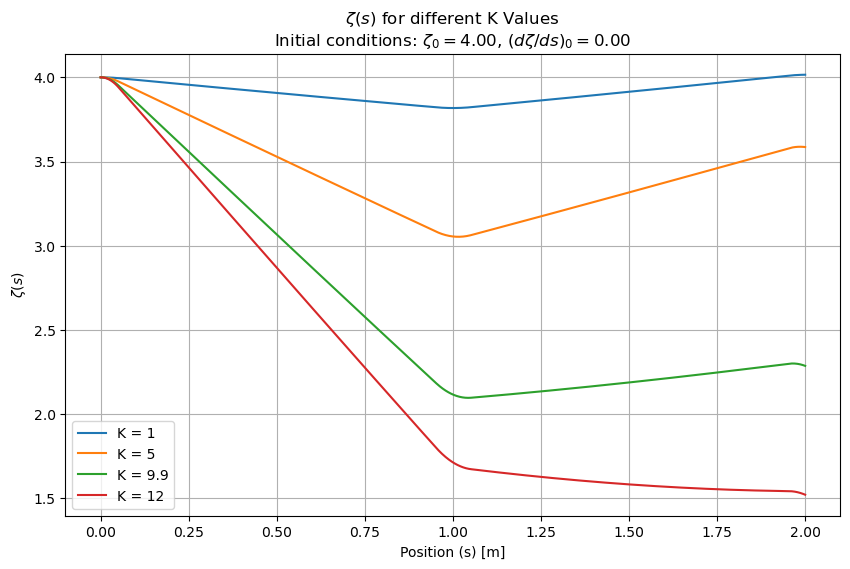

In [12]:
# Constants
l = 0.1  # [m]
L = 1    # [m]
K_max = 2 / (l * L)
print('l = ', f'{l:.1f}', 'm', '\nL = ', f'{L:.1f}', 'm', '\nK_max =', K_max, 'm⁻²')

# Define the range of s
s = np.linspace(0, 2*L, 1000)  # Define the positions to solve over

# Initial conditions for u(s) and v(s)
u0 = 4  # Initial value of zeta(s) at s=0 [m]
v0 = 0  # Initial value of zeta'(s) at s=0 []

# Define the conditions for the piecewise function K(s)
conditions = [
    s < l/2,                            # Condition for the first 1/2 QF
    (s >= l/2) & (s < L - l/2),         # Condition for the first drift
    (s >= L - l/2) & (s < L + l/2),     # Condition for the QD
    (s >= L + l/2) & (s < 2*L - l/2),   # Condition for the second drift
    (s >= 2*L - l/2) & (s < 2*L + l/2)  # Condition for the second 1/2 QF
]

# conditions = [
#     s < l,                           # Condition for the first 1/2 QF
#     (s >= l) & (s < L),        # Condition for the first drift
#     (s >= L) & (s < L + l),    # Condition for the QD
#     (s >= L + l) & (s < 2*L),  # Condition for the second drift
#     (s >= 2*L) & (s < 2*L + l) # Condition for the second 1/2 QF
# ]

functions = [1, 0, -1, 0, 1]  # Assign K = 1, 0, or -1 based on the segment

# Define K_array using np.piecewise
K_base_array = np.piecewise(s, conditions, functions)

# Function to solve the differential equations
def solve_ode(K_array, u0, v0, s, ds):
    u = np.zeros(len(s))
    v = np.zeros(len(s))
    u[0] = u0
    v[0] = v0
    
    # Solve using the Euler method
    for i in range(1, len(s)):
        u[i] = u[i-1] + v[i-1] * ds
        v[i] = v[i-1] + (1 / u[i-1]**3 - K_array[i-1] * u[i-1]) * ds
    
    return u, v

# Run the solver for different values of K
K_values = [1, 5, 9.9, 12]
plt.figure(figsize=(10, 6))

for K_val in K_values:
    # Update K_array for the current K_value
    K_array = K_val * K_base_array

    # Solve the ODE
    ds = s[1] - s[0]
    u, v = solve_ode(K_array, u0, v0, s, ds)
    
    # Plot the results
    plt.plot(s, u, label=f'K = {K_val}')

plt.xlabel('Position (s) [m]')
plt.ylabel(r'$\zeta(s)$')
plt.title(r'$\zeta(s)$ for different K Values ' + '\n' + r'Initial conditions: $\zeta_0 = ' + f'{u0:.2f}' + r'$, $(d\zeta/ds)_0 = ' + f'{v0:.2f}' + r'$')
plt.legend()
plt.grid(True)
plt.show()


##### Multiple Turns

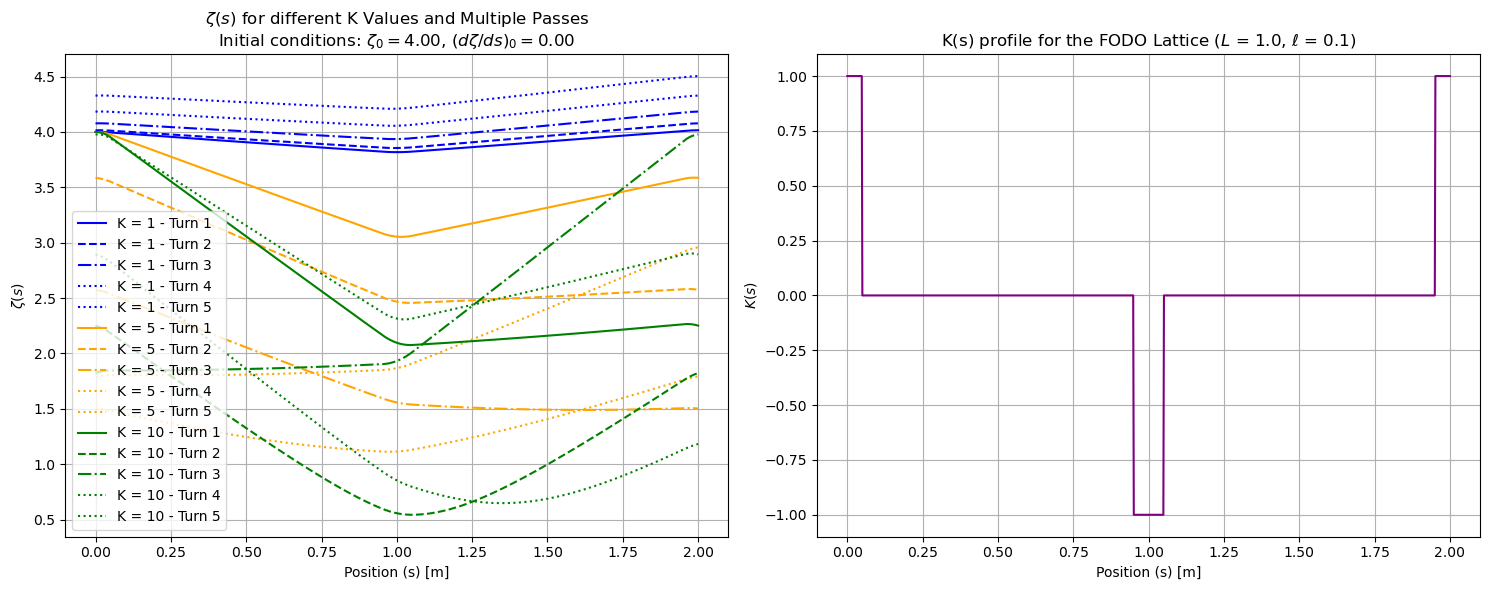

In [ ]:
# Number of passes (turns)
N = 5 

# Define K values and corresponding colors
K_values = [1, 5, 10]
colors = ['blue', 'orange', 'green']  # Blue, Green, Red
line_styles = ['-', '--', '-.', ':', ':']  # Solid, Dashed, Dash-dotted, ... for 1st, 2nd, 3rd, ... turns

# Initial conditions
u00 = 4  # Initial value of zeta(s) at s=0 [m]
v00 = 0  # Initial value of zeta'(s) at s=0 []

# Plotting the results
fig, axes = plt.subplots(1, 2, figsize=(15, 6))  # Create two subplots (1 row, 2 columns)

# First subplot for Zeta(s)
ax1 = axes[0]
for K_val, color in zip(K_values, colors):
    # Update K_array for the current K_value
    K_array = K_val * K_base_array
    
    # Fixed initial conditions for the first pass
    u0 = u00
    v0 = v00
    
    # Solve first pass
    u, v = solve_ode(K_array, u0, v0, s, s[1] - s[0])
    
    # Plot the first pass with the specific color and line style
    ax1.plot(s, u, label=f'K = {K_val} - Turn 1', color=color, linestyle=line_styles[0])
    
    # For subsequent turns, use the final values from the previous turn as initial conditions
    for turn in range(2, N + 1):
        u0 = u[-1]  # Take the final u value from the previous pass
        v0 = v[-1]  # Take the final v value from the previous pass
        
        u, v = solve_ode(K_array, u0, v0, s, s[1] - s[0])
        
        # Plot each subsequent pass with the same color but different line style
        ax1.plot(s, u, label=f'K = {K_val} - Turn {turn}', color=color, linestyle=line_styles[turn-1])

# Labels and title for the first subplot
ax1.set_xlabel('Position (s) [m]')
ax1.set_ylabel(r'$\zeta(s)$')
ax1.set_title(r'$\zeta(s)$ for different K Values and Multiple Passes' + '\n' + r'Initial conditions: $\zeta_0 = ' + f'{u00:.2f}' + r'$, $(d\zeta/ds)_0 = ' + f'{v00:.2f}' + r'$')
ax1.legend()
ax1.grid(True)

# Second subplot for K(s)
ax2 = axes[1]
ax2.plot(s, K_base_array, label=r'$K(s)$ profile', color='purple')
ax2.set_xlabel('Position (s) [m]')
ax2.set_ylabel(r'$K(s)$')
ax2.set_title(f'Normalized K(s) profile for the FODO Lattice ($L$ = {L:.1f}, $\ell$ = {l:.1f})')
ax2.grid(True)

# Show the plot
plt.tight_layout()
plt.show()

##### Multiple Turns (concatenated)

l =  0.1 m 
L =  1.0 m 
K_max = 20.0 m⁻²


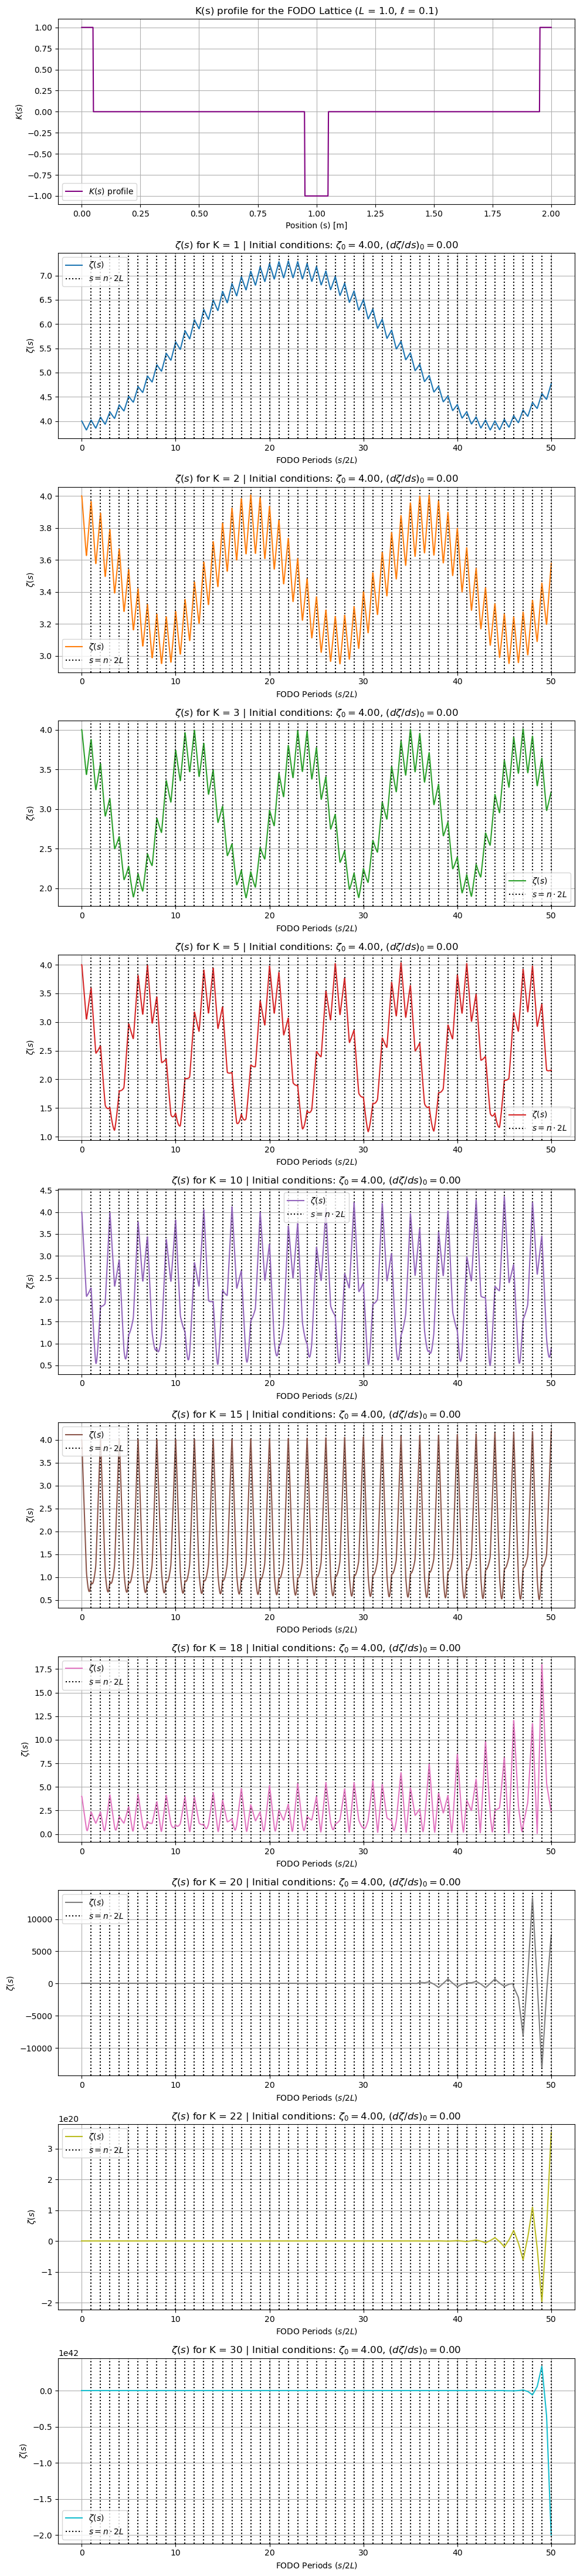

In [15]:
# Constants
l = 0.1  # [m]
L = 1    # [m]
K_max = 2 / (l * L)
print('l = ', f'{l:.1f}', 'm', '\nL = ', f'{L:.1f}', 'm', '\nK_max =', K_max, 'm⁻²')

# Define the range of s
s = np.linspace(0, 2*L, 1000)  # Define the positions to solve over

# Initial conditions for u(s) and v(s)
u00 = 4  # Initial value of zeta(s) at s=0 [m]
v00 = 0  # Initial value of zeta'(s) at s=0 []

# Define the conditions for the piecewise function K(s)
conditions = [
    s < l/2,                            # Condition for the first 1/2 QF
    (s >= l/2) & (s < L - l/2),         # Condition for the first drift
    (s >= L - l/2) & (s < L + l/2),     # Condition for the QD
    (s >= L + l/2) & (s < 2*L - l/2),   # Condition for the second drift
    (s >= 2*L - l/2) & (s < 2*L + l/2)  # Condition for the second 1/2 QF
]

functions = [1, 0, -1, 0, 1]  # Assign K = 1, 0, or -1 based on the segment

# Define K_array using np.piecewise
K_base_array = np.piecewise(s, conditions, functions)

# Function to solve the differential equations
def solve_ode(K_array, u0, v0, s, ds):
    u = np.zeros(len(s))
    v = np.zeros(len(s))
    u[0] = u0
    v[0] = v0
    
    # Solve using the Euler method
    for i in range(1, len(s)):
        u[i] = u[i-1] + v[i-1] * ds
        v[i] = v[i-1] + (1 / u[i-1]**3 - K_array[i-1] * u[i-1]) * ds
    
    return u, v


# Number of passes (turns)
N = 50

# Define K values and corresponding colors
K_values = [1, 2, 3, 5, 10, 15, 18, 20, 22, 30]
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', 
          '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']
colors = colors[:len(K_values)]

# Create a figure with multiple subplots (len(K_values) + 1 rows)
fig, axes = plt.subplots(len(K_values) + 1, 1, figsize=(10, 4 * (len(K_values) + 1)))

# First subplot for K(s)
ax = axes[0]
ax.plot(s, K_base_array, label=r'$K(s)$ profile', color='purple')

# for K_val, color in zip(K_values, colors): # Adding focal points
#     f = 1 / (K_val * l)
#     ax.plot(f, 0, marker='o', color=color, linestyle='None', label=fr'$f$ for $K={K_val}$')

ax.set_xlabel('Position (s) [m]')
ax.set_ylabel(r'$K(s)$')
ax.set_title(f'K(s) profile for the FODO Lattice ($L$ = {L:.1f}, $\ell$ = {l:.1f})')
ax.grid(True)
ax.legend()

# Loop over different K values and plot for each pass
for idx, (K_val, color) in enumerate(zip(K_values, colors)):
    # Create an extended s range for the concatenated plot
    extended_s = np.concatenate([s + 2 * L * n for n in range(N)])

    # Initialize u and v for the first pass
    u = np.zeros(len(extended_s))
    v = np.zeros(len(extended_s))
    u0 = u00
    v0 = v00
    
    # Solve for the first pass
    for n in range(N):
        start_idx = n * len(s)
        end_idx = (n + 1) * len(s)

        # Solve the ODE for this segment
        K_array = K_val * K_base_array
        u_segment, v_segment = solve_ode(K_array, u0, v0, s, s[1] - s[0])
        
        # Add the segment to the full solution
        u[start_idx:end_idx] = u_segment
        v[start_idx:end_idx] = v_segment
        
        # Update initial conditions for the next turn
        u0 = u_segment[-1]
        v0 = v_segment[-1]
        
        # Plot the segment with a specific color and line style (solid line now)
        ax = axes[idx + 1]  # Select the corresponding subplot for this K value
        ax.plot(extended_s[start_idx:end_idx]/(2*L), u_segment, label=f'K = {K_val} - Turn {n+1}', color=color, linestyle='-')
        
        # Add vertical lines to indicate end of each pass
        ax.axvline(x=extended_s[end_idx-1]/(2*L), color='black', linestyle=':', label='$s = n \cdot 2L$' if n == 0 else "")

    # Labels and title for the subplot of zeta(s) vs s/2L
    ax.set_xlabel(r'FODO Periods ($s/2L$)')
    ax.set_ylabel(r'$\zeta(s)$')
    ax.set_title(f'$\zeta(s)$ for K = {K_val} | ' + r'Initial conditions: $\zeta_0 = ' + f'{u00:.2f}' + r'$, $(d\zeta/ds)_0 = ' + f'{v00:.2f}' + r'$')
    ax.grid(True)
    
    ax.legend([r'$\zeta(s)$', '$s = n \cdot 2L$'])

# Tight layout for subplots
plt.tight_layout()

# Show the plot
plt.show()